In [104]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, auc
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [196]:
df=pd.read_csv("/content/drive/My Drive/Colab Notebooks/Machine Learning/bankloan.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


In [197]:
df.head()

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP.Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal.Loan       5000 non-null   int64  
 10  Securities.Account  5000 non-null   int64  
 11  CD.Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [199]:
df.shape

(5000, 14)

In [200]:
df.describe()

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [201]:
df.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIP.Code,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal.Loan,0


In [202]:
print("Number of Duplicates: ",df.duplicated().sum())

Number of Duplicates:  0


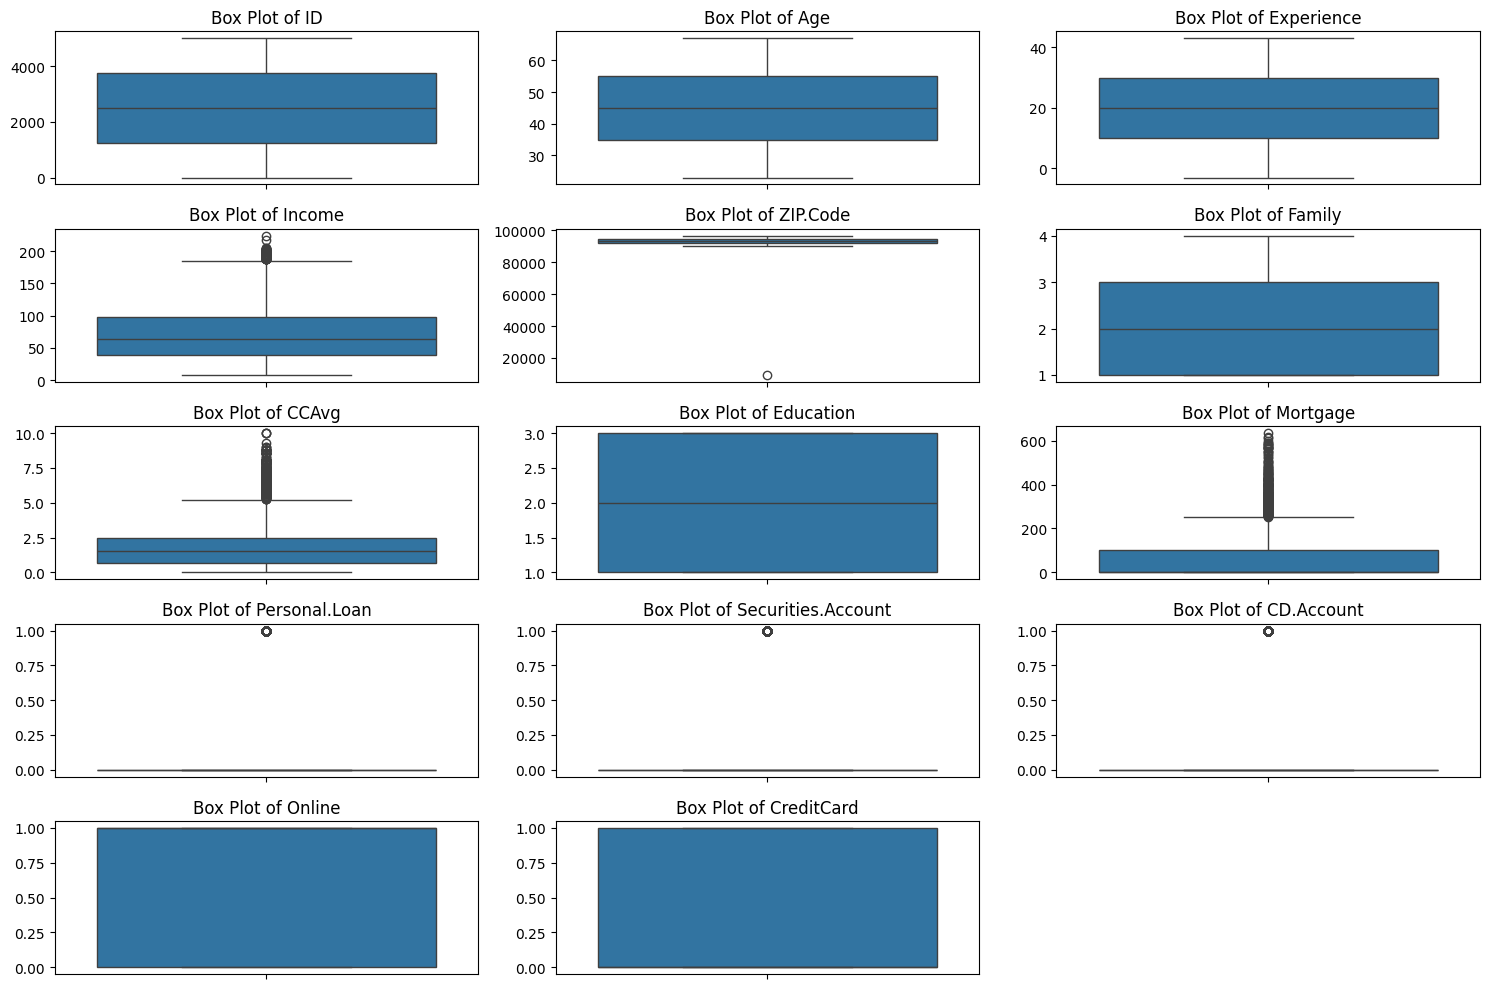

In [203]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i)
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel('')
plt.tight_layout()
plt.show()


In [204]:
print(f"Shape of DataFrame before outlier removal: {df.shape}")

outlier_cols = ['Income', 'CCAvg', 'Mortgage']

# Iterative outlier removal
while True:
    initial_shape = df.shape[0]
    for col in outlier_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    if df.shape[0] == initial_shape:
        break

print(f"Shape of DataFrame after iterative outlier removal: {df.shape}")

Shape of DataFrame before outlier removal: (5000, 14)
Shape of DataFrame after iterative outlier removal: (3011, 14)


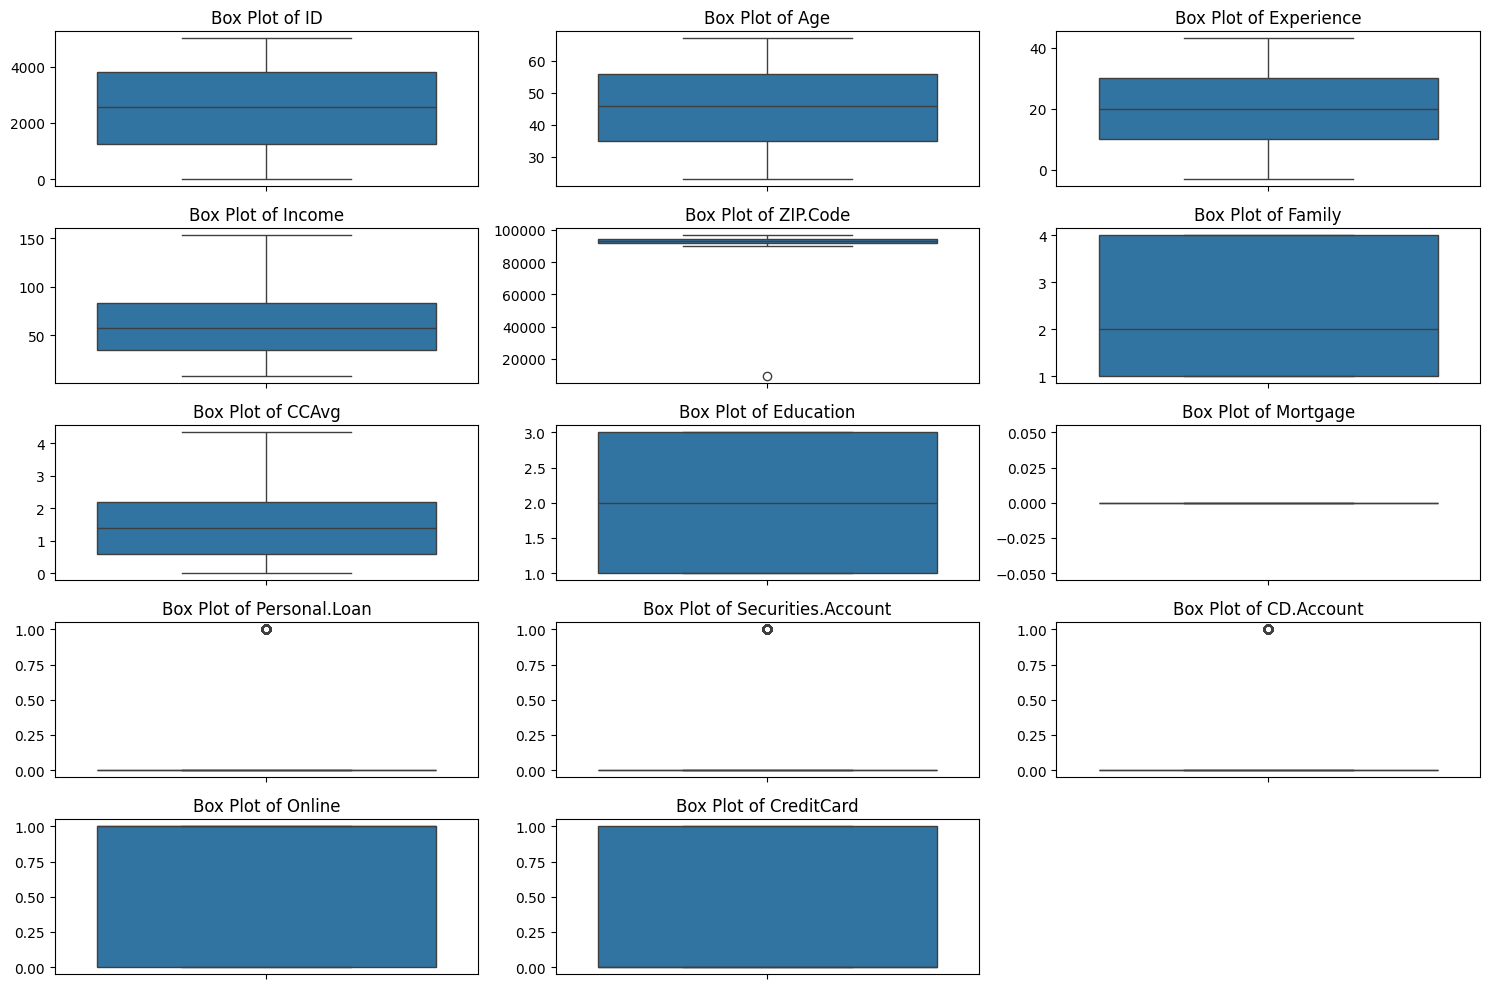

In [205]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i)
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel('')
plt.tight_layout()
plt.show()


In [206]:
df['Experience'] = df['Experience'].apply(lambda x: max(x, 0))
print("Minimum experience after correction:", df['Experience'].min())


Minimum experience after correction: 0


In [207]:
df_preprocessed = df.drop(columns=['ID', 'ZIP.Code'])
display(df_preprocessed.head())


,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1


In [208]:
numerical_cols = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']

scaler = StandardScaler()
# Ensure we scale the latest version of df
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

display(df.head())

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,1,-1.773145,-1.666248,-0.383990,91107,4,0.128485,1,0.0,0,1,0,0,0
1,2,-0.043458,-0.109064,-0.830443,90089,3,0.031414,1,0.0,0,1,0,0,0
2,3,-0.562364,-0.455105,-1.515005,94720,1,-0.453944,1,0.0,0,0,0,0,0
3,4,-0.908301,-0.974166,1.133950,94112,1,1.196272,2,0.0,0,0,0,0,0
4,5,-0.908301,-1.060676,-0.503044,91330,4,-0.453944,2,0.0,0,0,0,0,1


In [209]:
# Drop ID and ZIP.Code if they haven't been dropped from df yet, then split
X = df.drop(['Personal.Loan', 'ID', 'ZIP.Code'], axis=1, errors='ignore')
y = df['Personal.Loan']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (3011, 11)
Target (y) shape: (3011,)


In [210]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (2408, 11)
X_test shape: (603, 11)
y_train shape: (2408,)
y_test shape: (603,)


In [211]:
# model building
model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=5000)
model.fit(X_train, y_train)
print("Model trained")

Model trained


In [212]:
y_pred = model.predict(X_test)
print("Predictions made")

Predictions made


In [213]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = accuracy_score(y_test, y_pred)
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.9069767441860465
Test Accuracy: 0.8839137645107794


In [214]:
#Print confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[512  64]
 [  6  21]]


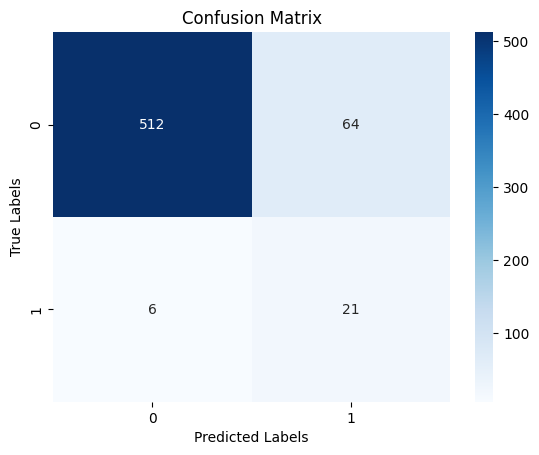

In [215]:
#display confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [216]:
# print classification report
class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94       576
           1       0.25      0.78      0.38        27

    accuracy                           0.88       603
   macro avg       0.62      0.83      0.66       603
weighted avg       0.96      0.88      0.91       603



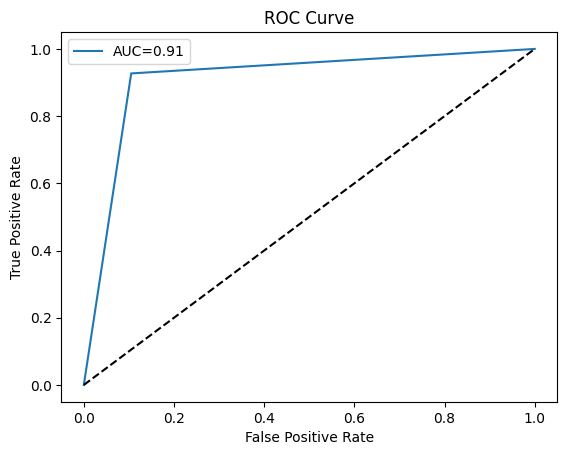

In [217]:
#display auc_roc_curve
plt.plot(fpr, tpr, label='AUC={:.2f}'.format(auc_score))
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()